In [ ]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from torch import nn

import pytorch_lightning as pl
from pytorch_lightning import LightningModule
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics import KLDivergence

from src.dataset import *
from src.params import *
from src.utils import *


In [ ]:
%pip install -e ..

# Design baseline model
- simple CNN with VGG-ish architecture
- hardcoded because objective isnt to fine tune that

## Conv block and model

In [2]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride= 1, kernel= 3, padding= 1):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels= in_channels,
                      out_channels= out_channels,
                      stride= stride,
                      padding= padding,
                      kernel_size= kernel,
                      bias= False),
            nn.BatchNorm2d(num_features= out_channels),
            nn.ReLU()
        )

    def forward(self,x):
        return self.block(x)

In [3]:
class BaselineModel(nn.Module):

    def __init__(self, n_classes, n_channels):

        super().__init__()
        self.n_classes = n_classes
        self.n_channels = n_channels

        self.block1 = nn.Sequential(
            ConvBlock(in_channels= self.n_channels,
                      out_channels= 32),
            ConvBlock(in_channels= 32,
                      out_channels= 64),
            nn.MaxPool2d(kernel_size= 3, stride= 2, padding= 1),
            nn.Dropout(0.3)
        )

        self.block2 = nn.Sequential(
            ConvBlock(in_channels= 64,
                      out_channels= 128),
            ConvBlock(in_channels= 128,
                      out_channels= 256),
            nn.MaxPool2d(kernel_size= 3, stride= 2, padding= 1),
            nn.Dropout(0.3)
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.Dropout(0.3),
            nn.Linear(64, self.n_classes)
        )

    def forward(self,x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.head(x)

        return nn.functional.log_softmax(x, dim= 1)


# Lighntning

## lightning module

In [4]:
class BrainLightning(LightningModule):

    def __init__(self, model, n_classes= 6, lr=1e-3):

        super().__init__()
        self.save_hyperparameters(ignore= ["model"])
        self.model = model
        #the model returns y_pred as log_proba, but y_true is proba. This is expected for the loss
        self.criterion = nn.KLDivLoss(reduction= "batchmean")
        self.train_kl = KLDivergence(reduction= "mean")
        self.val_kl = KLDivergence(reduction= "mean")


    def forward(self, x):
        return self.model(x)

    def training_step(self,batch, batch_idx):
        x, y = batch
        logits = self(x) #logits already returned after log_softmax so as log-space distribution
        loss = self.criterion(logits, y)
        self.train_kl.update(y, torch.exp(logits)) #check if correct for log
        self.log_dict(
            {"train_loss": loss,
             "train_kl": self.train_kl},
            on_step= False, on_epoch= True, prog_bar= True)
        return loss

    def validation_step(self,batch, batch_idx):

        x, y = batch
        logits = self(x) #logits already returned after log_softmax so as log-space distribution
        loss = self.criterion(logits, y)
        self.val_kl.update(y, torch.exp(logits)) #check if correct for log
        self.log_dict(
            {"val_loss": loss,
             "val_kl": self.val_kl},
            on_step= False, on_epoch= True, prog_bar= True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr = self.hparams.lr,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=50, eta_min=1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

    def on_train_epoch_end(self) -> None:

        train_loss = self.trainer.callback_metrics.get("train_loss", float("nan"))
        train_kl = self.trainer.callback_metrics.get("train_kl", float("nan"))
        print(f"Epoch {self.current_epoch:03d} - train_loss: {train_loss:.4f} - train_kl: {train_kl:.4f}")


    def on_validation_epoch_end(self):
        val_loss = self.trainer.callback_metrics.get("val_loss", float("nan"))
        val_kl = self.trainer.callback_metrics.get("val_kl", float("nan"))
        print(f"Epoch {self.current_epoch:03d} | val_loss:   {val_loss:.4f} | val_kl:   {val_kl:.4f}")


## loggers, callbacks et trainers


In [ ]:
callbacks = [
    ModelCheckpoint(
        dirpath="checkpoints/",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename="{epoch:02d}-{val_loss:.3f}-{val_kl:.3f}",
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        min_delta=1e-4,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(leave= True),
]

logger = TensorBoardLogger(save_dir="logs/", name="base_cnn", version=None)


In [6]:
trainer_test = pl.Trainer(fast_dev_run=True, accelerator="auto", devices="auto")

trainer_overfit = pl.Trainer(
    overfit_batches=10, accelerator="auto", devices="auto", max_epochs=50, log_every_n_steps= 1
)

trainer_full = pl.Trainer(
    max_epochs=50,
    accelerator="mps",
    devices="auto",
    callbacks=callbacks,
    logger=logger,
    precision="bf16-mixed",
    enable_progress_bar=True,
    log_every_n_steps=1,
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable Lit

# Train et analysis


## Instantiation


In [7]:
import time
df = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata= df, batch_size= 32, num_workers= 8)
model = BaselineModel(n_classes=6, n_channels=4)
lit = BrainLightning(model=model)

In [8]:
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",

    devices="auto",
    callbacks = callbacks,
    logger = logger

)

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [9]:

trainer.fit(lit, datamodule=dm)


[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273.json
[setup] Cache loaded — 5 folds found


/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BaselineModel │  406 K │ train │     0 │
│ 1 │ criterion │ KLDivLoss     │      0 │ train │     0 │
│ 2 │ train_kl  │ KLDivergence  │      0 │ train │     0 │
│ 3 │ val_kl    │ KLDivergence  │      0 │ train │     0 │
└───┴───────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 406 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 406 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 021 | val_loss:   0.8428 | val_kl:   0.8428

Epoch 021 - train_loss: 0.3738 - train_kl: 0.3738

Output()

Epoch 022 | val_loss:   0.9475 | val_kl:   0.9475

Epoch 022 - train_loss: 0.3646 - train_kl: 0.3646

In [12]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

def plot_losses(log_dir="logs/base_cnn"):
    versions = sorted(Path(log_dir).glob("version_*"), key=lambda p: int(p.name.split("_")[-1]))
    ea = EventAccumulator(str(versions[-1]))
    ea.Reload()

    def to_df(tag):
        events = ea.Scalars(tag)
        return pd.DataFrame({"epoch": [e.step for e in events], tag: [e.value for e in events]})

    train = to_df("train_loss")
    val   = to_df("val_loss")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train["epoch"], train["train_loss"], label="train loss")
    ax.plot(val["epoch"],   val["val_loss"],     label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

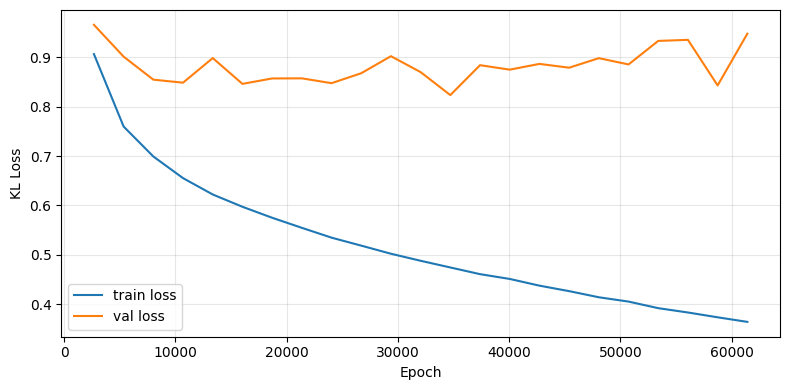

In [13]:
plot_losses()

# Iteration on updated baseline
- reduced lr
- changed cosine to ReduceLR scheduler
- add a check of train set dist vs val set dist

In [ ]:
# instantiations

df = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata= df, batch_size= 32, num_workers= 8)
model = BaselineModel(n_classes=6, n_channels=4)
lit = BrainLightning(model=model)